# ============================
# House Price Prediction Model
# ============================

In [65]:
# Day 1: Load & Explore Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Load dataset
df = pd.read_csv(r"E:\The Developers Arena\House Price Prediction\house_prices.csv")

In [67]:
# Quick overview
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


In [69]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [70]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


# Visualize relationships


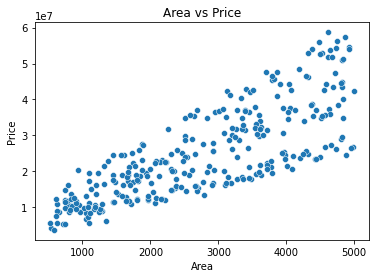

In [71]:
sns.scatterplot(x="Area", y="Price", data=df)
plt.title("Area vs Price")
plt.show()

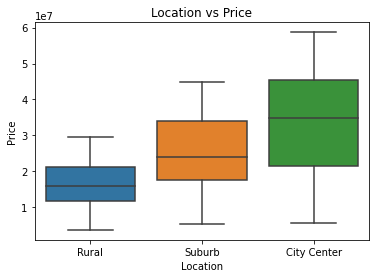

In [72]:
sns.boxplot(x="Location", y="Price", data=df)
plt.title("Location vs Price")
plt.show()

# ============================
# Day 2: Data Preparation
# ============================


In [73]:
from sklearn.model_selection import train_test_split

In [74]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["Location", "Property_Type"], drop_first=True)

In [75]:
# Features & target
X = df_encoded.drop(["Property_ID", "Price"], axis=1)
y = df_encoded["Price"]

In [76]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# Day 3–4: Build First Model
# ============================

In [77]:
from sklearn.linear_model import LinearRegression

In [78]:
# Train model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [79]:
# Predictions
y_pred = lin_reg.predict(X_test)

# ============================
# Day 5: Evaluate Model
# ============================


In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [81]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [82]:
print("Linear Regression Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

Linear Regression Performance:
MAE: 2188736.343703812
MSE: 8454330868276.601
R²: 0.9406371185112241


# Visualize Prediction vs Actual

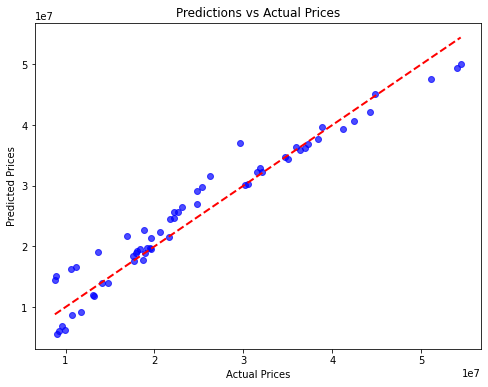

In [83]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predictions vs Actual Prices")

# Add perfect prediction reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2)

plt.show()

# ============================
# Day 6: Improve Model
# ============================


In [84]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Polynomial Regression


In [85]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [86]:
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_poly, y_train)
y_pred_poly = lin_reg_poly.predict(X_test_poly)

In [87]:
print("Polynomial Regression R²:", r2_score(y_test, y_pred_poly))

Polynomial Regression R²: 1.0


# Decision Tree


In [88]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree R²:", r2_score(y_test, y_pred_dt))

Decision Tree R²: 0.935648766050682


# Random Forest


In [89]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest R²: 0.9710688215749718


# Feature Importance (Random Forest)


In [90]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

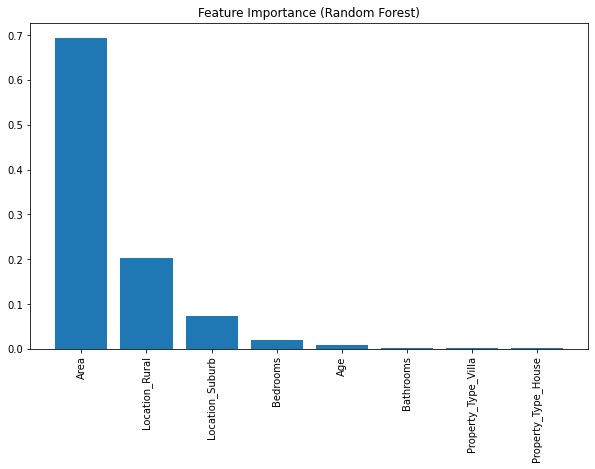

In [91]:
plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()

# Coefficients (Linear Regression)


In [92]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Linear Regression Coefficients:\n", coefficients)

Linear Regression Coefficients:
                Feature   Coefficient
1             Bedrooms  1.585709e+06
2            Bathrooms  4.545940e+05
7  Property_Type_Villa  6.372497e+04
0                 Area  7.558956e+03
3                  Age -8.244368e+04
6  Property_Type_House -6.079037e+05
5      Location_Suburb -8.633012e+06
4       Location_Rural -1.672813e+07
